In [4]:
import numpy as np
import scipy.optimize as sp_opt
import scipy.integrate as sp_int
from matplotlib import pyplot as plt
import matplotlib.cm as cm


In [5]:
def fun(y, x):
    return (y - y / x + np.sin(y / x))

def fprime(y, x):
    return (x - 1 + np.cos(y/x) * 1/x)

def fint(y, x):
    return (y**2 - y**2/x - np.cos(y/x) * x)


/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_92008/2302014507.py:8: RuntimeWarning: divide by zero encountered in divide
  return (y**2 - y**2/x - np.cos(y/x) * x)
/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_92008/2302014507.py:8: RuntimeWarning: invalid value encountered in divide
  return (y**2 - y**2/x - np.cos(y/x) * x)
/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_92008/2302014507.py:8: RuntimeWarning: invalid value encountered in cos
  return (y**2 - y**2/x - np.cos(y/x) * x)
/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_92008/3527024918.py:12: RuntimeWarning: overflow encountered in exp
  ps = np.exp(-fint(zs, x))
/Users/rafael.calsaverini/miniforge3/envs/sandbox/lib/python3.10/site-packages/numpy/lib/function_base.py:4832: RuntimeWarning: overflow encountered in add
  ret = (d * (y[tuple(slice1)] + y[tuple(slice2)]) / 2.0).sum(axis)
/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_92008/3527024918.py:14: RuntimeWa

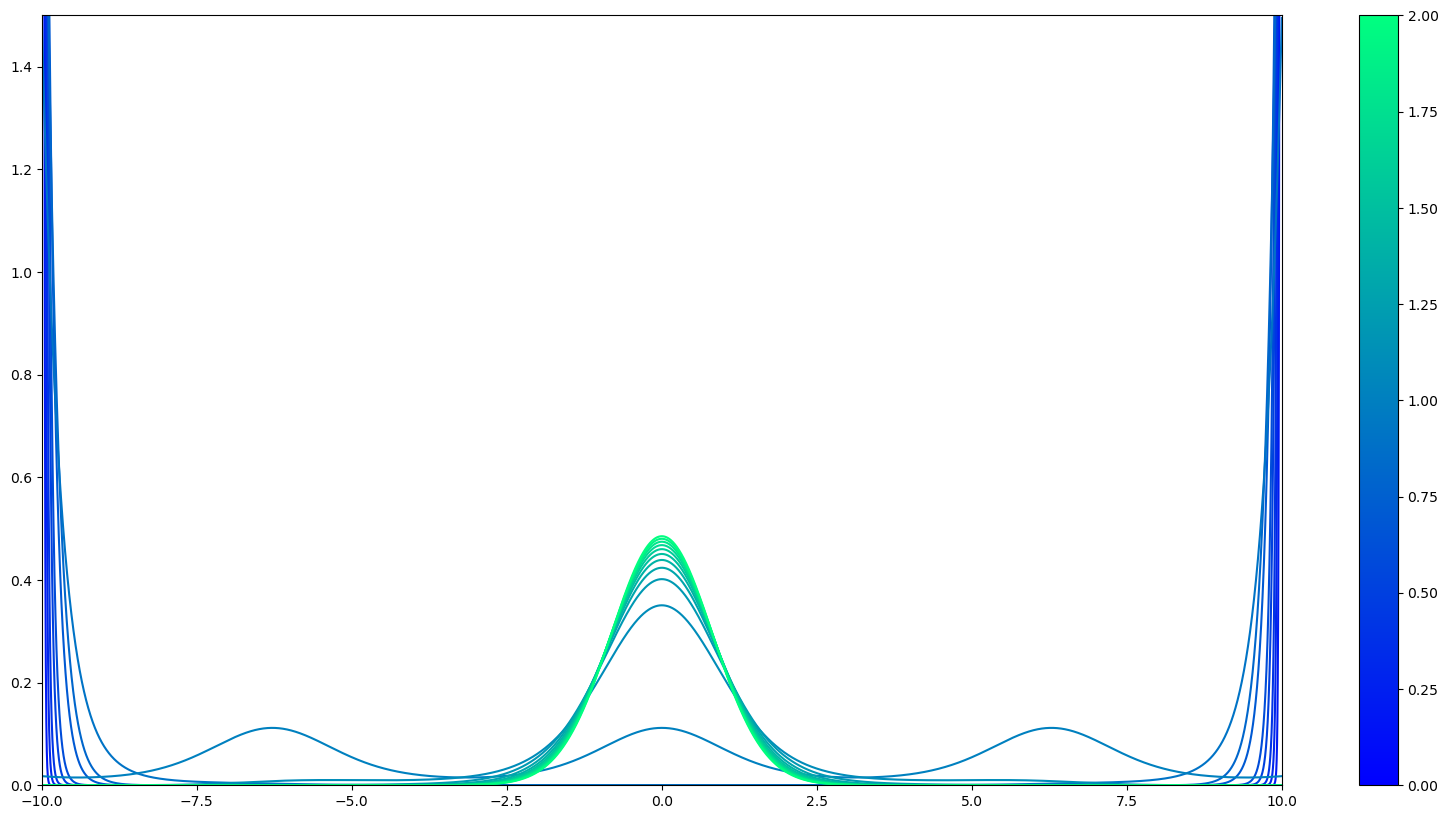

In [8]:
zs = np.linspace(-10, 10, 10001)
xs = np.linspace(0, 2, 21)
cs = (xs - xs.min())/(xs.max() - xs.min())
fig, ax = plt.subplots(figsize=(20, 10))
ax.set_xlim(zs.min(), zs.max())


color_map = cm.winter
max_p = 0.0

for (x, c) in zip(xs, cs):
    ps = np.exp(-fint(zs, x))
    norm_constant = sp_int.trapezoid(ps, zs)
    ax.plot(zs, ps/norm_constant, label=f"{x}", c=color_map(c))

ax.set_ylim(0, 1.5)    
sm = plt.cm.ScalarMappable(cmap=color_map, norm=plt.Normalize(vmin=xs.min(), vmax=xs.max()))
fig.colorbar(sm, ax=ax)

/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_77471/2588777156.py:8: RuntimeWarning: divide by zero encountered in double_scalars
  return (x * y**2/2 + x/(1-x) * np.cos(y))
/Users/rafael.calsaverini/miniforge3/envs/sandbox/lib/python3.9/site-packages/scipy/optimize/optimize.py:761: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


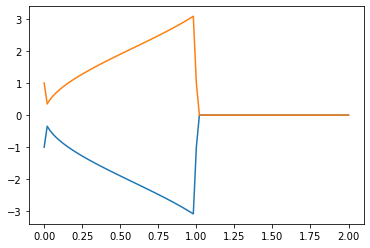

In [151]:
xs = np.linspace(0, 2, 101)

max_ls = [sp_opt.fmin(lambda z: fint(z, x), -1, disp=False) for x in xs]
max_rs = [sp_opt.fmin(lambda z: fint(z, x), 1, disp=False) for x in xs]

plt.plot(xs, max_ls)
plt.plot(xs, max_rs)